In [75]:
import sys
sys.path.append("..")
from src.outliers import *
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [76]:
#load processed data
data_path = Path("../data/processed/S&P500_stock_hist_5y.parquet")
df = pd.read_parquet(data_path)
df = df[df['ticker'].isin(['NVDA'])]

In [77]:
target_col = "excess_return"
df["outlier_iqr"] = detect_outliers_iqr(df[target_col])
df["outlier_winsorize"] = winsorize_series(df[target_col])
df['outlier_z'] = detect_outliers_zscore(df[target_col], threshold=3.0)
df = df.reset_index(drop=True)
df

Price,date,adj close,close,high,low,open,volume,ticker,daily_rtn,excess_return,outlier_iqr,outlier_winsorize,outlier_z
0,2020-08-20,12.101113,12.141000,12.375000,11.878750,11.975000,921388000,NVDA,0.000206,-0.002953,False,-0.002953,False
1,2020-08-21,12.641834,12.683500,12.808750,12.195250,12.201750,999868000,NVDA,0.044684,0.041242,False,0.041242,False
2,2020-08-24,12.678459,12.720250,12.912500,12.507500,12.883750,490564000,NVDA,0.002897,-0.007147,False,-0.007147,False
3,2020-08-25,12.708115,12.750000,12.761250,12.573750,12.630750,289076000,NVDA,0.002339,-0.001257,False,-0.001257,False
4,2020-08-26,12.731039,12.773000,12.868500,12.677750,12.799250,321244000,NVDA,0.001804,-0.008392,False,-0.008392,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2025-08-12,183.160004,183.160004,184.479996,179.460007,182.960007,145485700,NVDA,0.006042,-0.005303,False,-0.005303,False
1250,2025-08-13,181.589996,181.589996,183.970001,179.350006,182.619995,179871700,NVDA,-0.008572,-0.011802,False,-0.011802,False
1251,2025-08-14,182.020004,182.020004,183.020004,179.460007,179.750000,129554000,NVDA,0.002368,0.002065,False,0.002065,False
1252,2025-08-15,180.449997,180.449997,181.899994,178.039993,181.880005,156602200,NVDA,-0.008625,-0.005728,False,-0.005728,False


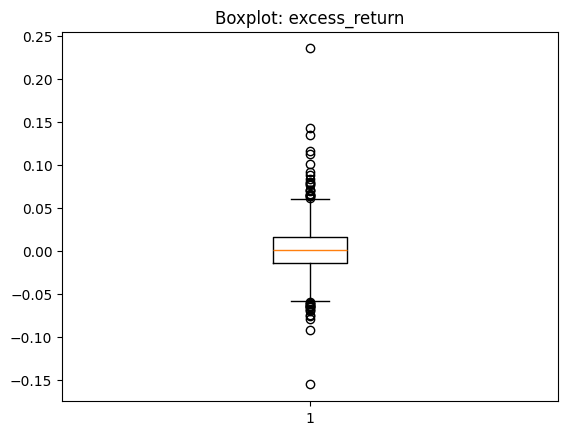

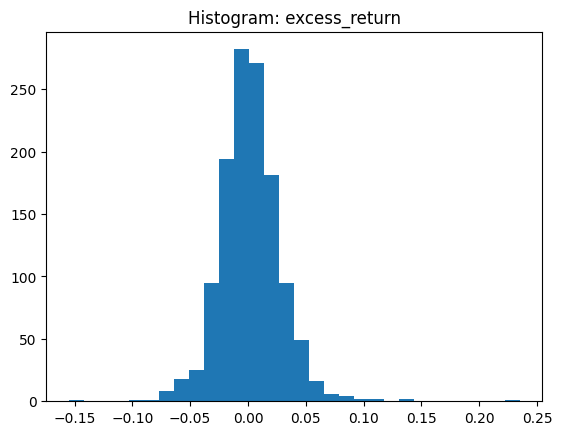

In [78]:
#visialize the graphs with outliers
plt.figure()
plt.boxplot(df[target_col])
plt.title(f'Boxplot: {target_col}')
plt.show()

plt.figure()
plt.hist(df[target_col], bins=30)
plt.title(f'Histogram: {target_col}')
plt.show()

In [79]:
summ_all = df[target_col].describe()[['mean', '50%', 'std']].rename({'50%': 'median'})
summ_filtered = df.loc[~df['outlier_iqr'], target_col].describe()[['mean', '50%', 'std']].rename({'50%': 'median'})
summ_w = None
if 'winsorize_series' in globals():
    w = winsorize_series(df[target_col])
    summ_w = w.describe()[['mean', '50%', 'std']].rename({'50%': 'median'})

comp = pd.concat(
    {
        'all': summ_all,
        'filtered_iqr': summ_filtered,
        **({'winsorized': summ_w} if summ_w is not None else {})
    }, axis=1
)
comp

,all,filtered_iqr,winsorized
mean,0.002134,0.001569,0.001947
median,0.000978,0.000895,0.000978
std,0.026709,0.021850,0.021474


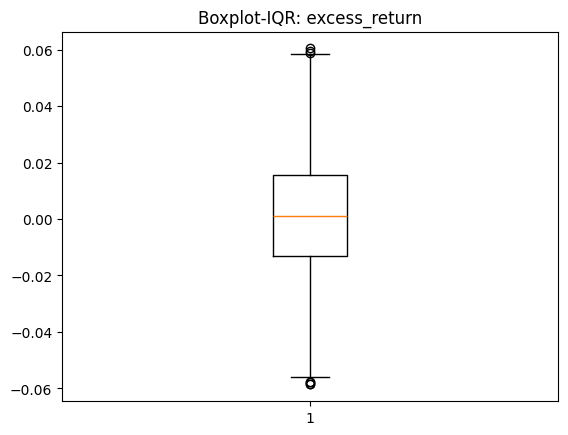

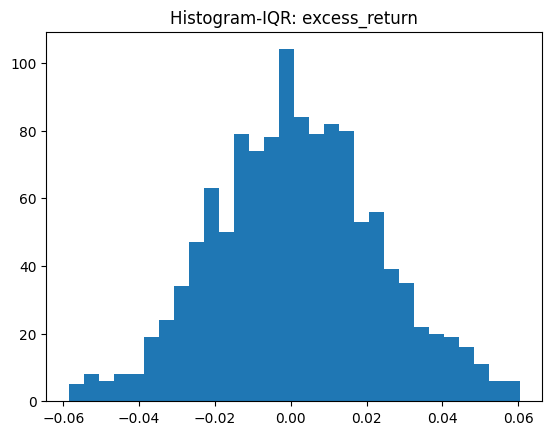

In [80]:
#visualize the graphs after applying IQR method
df1 = df.loc[~df["outlier_iqr"],target_col]
plt.figure()
plt.boxplot(df1)
plt.title(f'Boxplot-IQR: {target_col}')
plt.show()

plt.figure()
plt.hist(df1, bins=30)
plt.title(f'Histogram-IQR: {target_col}')
plt.show()

In [81]:
df2 = df.loc[~df["outlier_iqr"]]
df2.to_csv("../data/processed/NVDA_outliers.csv")

In [82]:
#use data exclude outliers to do regression fit
if 'daily_rtn' in df.columns:
    X_all = df[['daily_rtn']].to_numpy(); y_all = df[target_col].to_numpy()
    X_filtered = df.loc[~df['outlier_iqr'], ['daily_rtn']].to_numpy(); y_filtered = df.loc[~df['outlier_iqr'], target_col].to_numpy()
    X_win = df[["daily_rtn"]].to_numpy(); y_win = df["outlier_winsorize"].to_numpy()
    X_z = df.loc[~df["outlier_z"],["daily_rtn"]].to_numpy();y_z = df.loc[~df["outlier_z"],target_col].to_numpy()

    model_all = LinearRegression().fit(X_all, y_all)
    model_flt = LinearRegression().fit(X_filtered, y_filtered)
    model_win = LinearRegression().fit(X_win,y_win)
    model_zscore = LinearRegression().fit(X_z,y_z)

    mae_all = mean_absolute_error(y_all, model_all.predict(X_all))
    mae_flt = mean_absolute_error(y_filtered, model_flt.predict(X_filtered))
    mae_win = mean_absolute_error(y_win,model_win.predict(X_win))
    mae_zscore = mean_absolute_error(y_z,model_zscore.predict(X_z))

    results = pd.DataFrame({
        'slope': [model_all.coef_[0], model_flt.coef_[0],model_win.coef_[0],model_zscore.coef_[0]],
        'intercept': [model_all.intercept_, model_flt.intercept_,model_win.intercept_,model_zscore.intercept_],
        'r2': [model_all.score(X_all, y_all), model_flt.score(X_filtered, y_filtered),model_win.score(X_win,y_win),model_zscore.score(X_z,y_z)],
        'mae': [mae_all, mae_flt,mae_win,mae_zscore]
    }, index=['all', 'filtered_iqr',"filtered_winsorized","filtered_zscore"])
    results
else:
    results = None
    print("No 'daily_rtn' column; skip regression or engineer features.")
results

,slope,intercept,r2,mae
all,0.768831,0.000050,0.914463,0.005804
filtered_iqr,0.729301,0.000118,0.893415,0.005517
filtered_winsorized,0.587835,0.000354,0.827023,0.006465
filtered_zscore,0.750748,0.000060,0.905313,0.005626
